In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [2]:
data={
    "Study_Hours" : [1,7,4,9,4,7,8,7,8,2,9,2,3,3,1,6,4,7,4,5],
    "Sleep_Hours":  [4,4,4,7,8,6,8,8,6,5,8,8,6,5,7,5,8,7,7,6],
    "Attendance" : [50,90,79,86,60,95,93,92,90,55,87,47,54,76,44,53,41,89,67,98],
    "Score" :[42,100,87,100,81,100,100,100,100,74,100,56,62,81,63,97,76,100,73,100]
}
df=pd.DataFrame(data)
df

,Study_Hours,Sleep_Hours,Attendance,Score
0,1,4,50,42
1,7,4,90,100
2,4,4,79,87
3,9,7,86,100
4,4,8,60,81
5,7,6,95,100
6,8,8,93,100
7,7,8,92,100
8,8,6,90,100
9,2,5,55,74


In [3]:
X=df[["Study_Hours"]]
Y=df["Score"]

In [4]:
X_train, X_test, Y_train, Y_test= train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [5]:
print("Training samples = ",len(X_train))
print("Testing samples = ",len(X_test))

Training samples =  16
Testing samples =  4


In [6]:
print("Training data")
print(X_train)

print("\nTesting data")
print(X_test)

Training data
    Study_Hours
8             8
5             7
11            2
3             9
18            4
16            4
13            3
2             4
9             2
19            5
4             4
12            3
7             7
10            9
14            1
6             8

Testing data
    Study_Hours
0             1
17            7
15            6
1             7


In [7]:
model=LinearRegression()

In [8]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[5.34]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Study_Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,57.88
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [9]:
Y_pred=model.predict(X_test)


In [10]:
results=pd.DataFrame({
    "Actual values": Y_test.values,
    "Predicted Values":Y_pred
})

results

,Actual values,Predicted Values
0,42,63.216346
1,100,95.235577
2,97,89.899038
3,100,95.235577


In [16]:
errors = Y_test.values - Y_pred

print(errors)
mae=mean_absolute_error(Y_test, Y_pred)
print("MAE=",mae)

mse=mean_squared_error(Y_test,Y_pred)
print("MSE =",mse)

rmse=np.sqrt(mse)
print("RMSE = ",rmse)
Y_pred1=model.predict(X_train)

r2=r2_score(Y_test,Y_pred)
print("R2 =",r2)

s=r2_score(Y_train, Y_pred1)
print("Training score=",s)



[-21.21634615   4.76442308   7.10096154   4.76442308]
MAE= 9.461538461538456
MSE = 136.48911335059162
RMSE =  11.682855530673638
R2 = 0.776499251498366
Training score= 0.7777908240757225


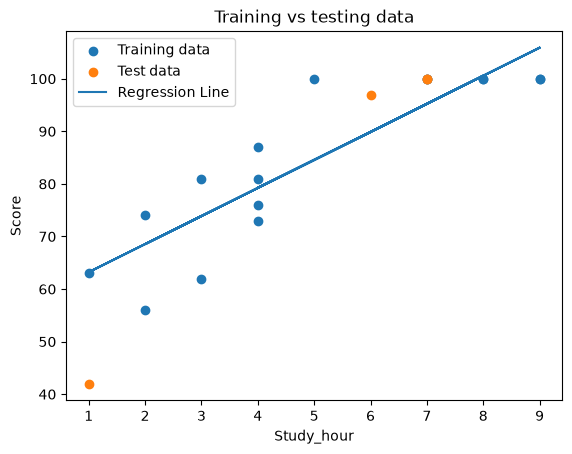

In [12]:
plt.scatter(X_train,Y_train,label="Training data")
plt.scatter(X_test, Y_test, label="Test data")
plt.plot(X,model.predict(X),label="Regression Line")

plt.xlabel("Study_hour")
plt.ylabel("Score")
plt.title("Training vs testing data")

plt.legend()
plt.show()

In [23]:
X=df[["Study_Hours","Attendance"]]
Y=df["Score"]
X_train,X_test, Y_train, Y_test=train_test_split( 
    X,
    Y,
    test_size=0.2,
    random_state=42

)
model=LinearRegression()
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)

error=Y_test.values-Y_pred
print(error)
mae=mean_absolute_error(Y_test,Y_pred)
print("MAE=",mae)
mse=mean_squared_error(Y_test,Y_pred)
print("MSE =",mse)
rmse=np.sqrt(mse)
print("RMSE=",rmse)
r2=r2_score(Y_test,Y_pred)
print("R2=",r2)

[-21.83882532   2.78872834  19.18968731   2.31961361]
MAE= 11.534213645375397
MSE = 214.58400084980582
RMSE= 14.648685976899287
R2= 0.6486189731248702
